In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from torchvision.models.segmentation import deeplabv3_resnet50

In [2]:
img_dir = "../data/patches/images"
mask_dir = "../data/patches/masks"

filenames = sorted(os.listdir(img_dir))
print("Total patches:", len(filenames))

Total patches: 11875


In [3]:
class BCSSDataset(Dataset):
    def __init__(self, img_dir, mask_dir, filenames, augment=False):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.filenames = filenames
        self.augment = augment
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                               std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img = Image.open(os.path.join(self.img_dir, fname)).convert("RGB")
        mask = Image.open(os.path.join(self.mask_dir, fname)).convert("L")

        img = TF.to_tensor(img)
        mask = torch.tensor(np.array(mask) / 255, dtype=torch.float32).unsqueeze(0)

        if self.augment:
            if random.random() > 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)
            if random.random() > 0.5:
                img = TF.vflip(img)
                mask = TF.vflip(mask)

        img = self.normalize(img)
        return img, mask

In [4]:
split = int(0.8 * len(filenames))
train_files = filenames[:split]
val_files = filenames[split:]

train_dataset = BCSSDataset(img_dir, mask_dir, train_files, augment=True)
val_dataset = BCSSDataset(img_dir, mask_dir, val_files, augment=False)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("Train patches:", len(train_dataset))
print("Val patches:", len(val_dataset))

Train patches: 9500
Val patches: 2375


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = deeplabv3_resnet50(weights="DEFAULT")
model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)
model = model.to(device)

Using device: cuda


In [6]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [7]:
def compute_metrics(pred, target, threshold=0.5, eps=1e-7):
    pred = (torch.sigmoid(pred) > threshold).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    dice = (2 * intersection + eps) / (pred.sum() + target.sum() + eps)
    iou = (intersection + eps) / (union + eps)

    return dice.item(), iou.item()

In [8]:
num_epochs = 30

history = {
    "train_loss": [], "val_loss": [],
    "train_dice": [], "val_dice": [],
    "train_iou": [], "val_iou": []
}

best_val_dice = 0

for epoch in range(num_epochs):
    model.train()
    train_loss, train_dice, train_iou = 0, 0, 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)['out']
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        d, i = compute_metrics(outputs, masks)
        train_loss += loss.item()
        train_dice += d
        train_iou += i

    model.eval()
    val_loss, val_dice, val_iou = 0, 0, 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)['out']
            loss = criterion(outputs, masks)

            d, i = compute_metrics(outputs, masks)
            val_loss += loss.item()
            val_dice += d
            val_iou += i

    n_train, n_val = len(train_loader), len(val_loader)
    history["train_loss"].append(train_loss / n_train)
    history["val_loss"].append(val_loss / n_val)
    history["train_dice"].append(train_dice / n_train)
    history["val_dice"].append(val_dice / n_val)
    history["train_iou"].append(train_iou / n_train)
    history["val_iou"].append(val_iou / n_val)

    current_val_dice = history["val_dice"][-1]

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {history['val_loss'][-1]:.4f} | "
          f"Train Dice: {history['train_dice'][-1]:.4f} | Val Dice: {current_val_dice:.4f}")

    if current_val_dice > best_val_dice:
        best_val_dice = current_val_dice
        torch.save(model.state_dict(), "../notebooks/best_model_augmented.pth")

print(f"\nTraining complete. Best Val Dice achieved: {best_val_dice:.4f}")

Epoch 1/30 | Train Loss: 0.3692 | Val Loss: 0.3429 | Train Dice: 0.8180 | Val Dice: 0.6911
Epoch 2/30 | Train Loss: 0.2997 | Val Loss: 0.3580 | Train Dice: 0.8571 | Val Dice: 0.6922
Epoch 3/30 | Train Loss: 0.2783 | Val Loss: 0.3079 | Train Dice: 0.8676 | Val Dice: 0.7116
Epoch 4/30 | Train Loss: 0.2677 | Val Loss: 0.3137 | Train Dice: 0.8731 | Val Dice: 0.7210
Epoch 5/30 | Train Loss: 0.2605 | Val Loss: 0.3461 | Train Dice: 0.8758 | Val Dice: 0.7049
Epoch 6/30 | Train Loss: 0.2526 | Val Loss: 0.3427 | Train Dice: 0.8777 | Val Dice: 0.6922
Epoch 7/30 | Train Loss: 0.2437 | Val Loss: 0.3803 | Train Dice: 0.8833 | Val Dice: 0.6485
Epoch 8/30 | Train Loss: 0.2367 | Val Loss: 0.3483 | Train Dice: 0.8864 | Val Dice: 0.6820
Epoch 9/30 | Train Loss: 0.2302 | Val Loss: 0.2955 | Train Dice: 0.8874 | Val Dice: 0.7090
Epoch 10/30 | Train Loss: 0.2286 | Val Loss: 0.3406 | Train Dice: 0.8900 | Val Dice: 0.7081
Epoch 11/30 | Train Loss: 0.2228 | Val Loss: 0.3529 | Train Dice: 0.8925 | Val Dice: 0.69

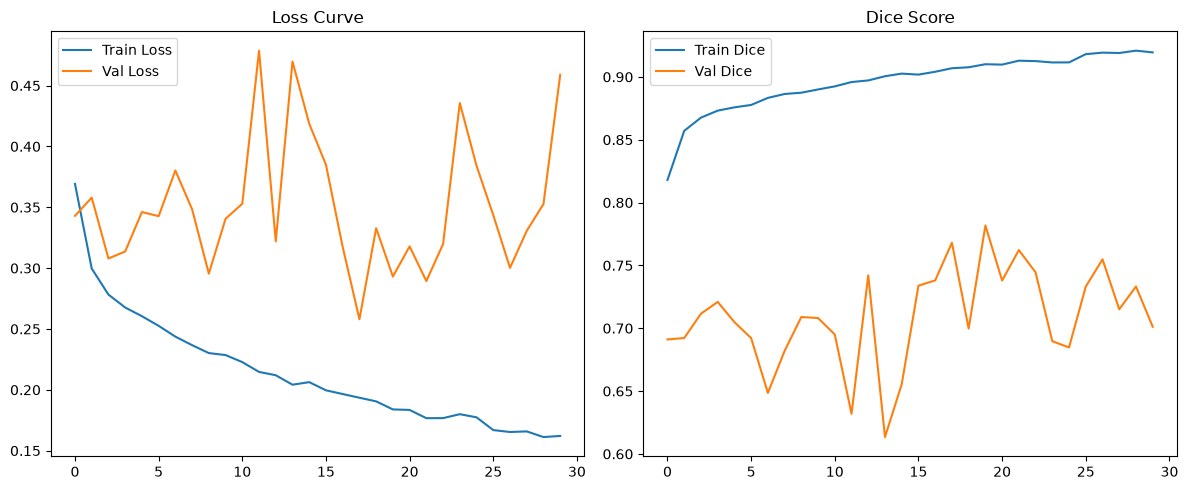

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss Curve")
axes[0].legend()

axes[1].plot(history["train_dice"], label="Train Dice")
axes[1].plot(history["val_dice"], label="Val Dice")
axes[1].set_title("Dice Score")
axes[1].legend()

plt.tight_layout()
plt.show()

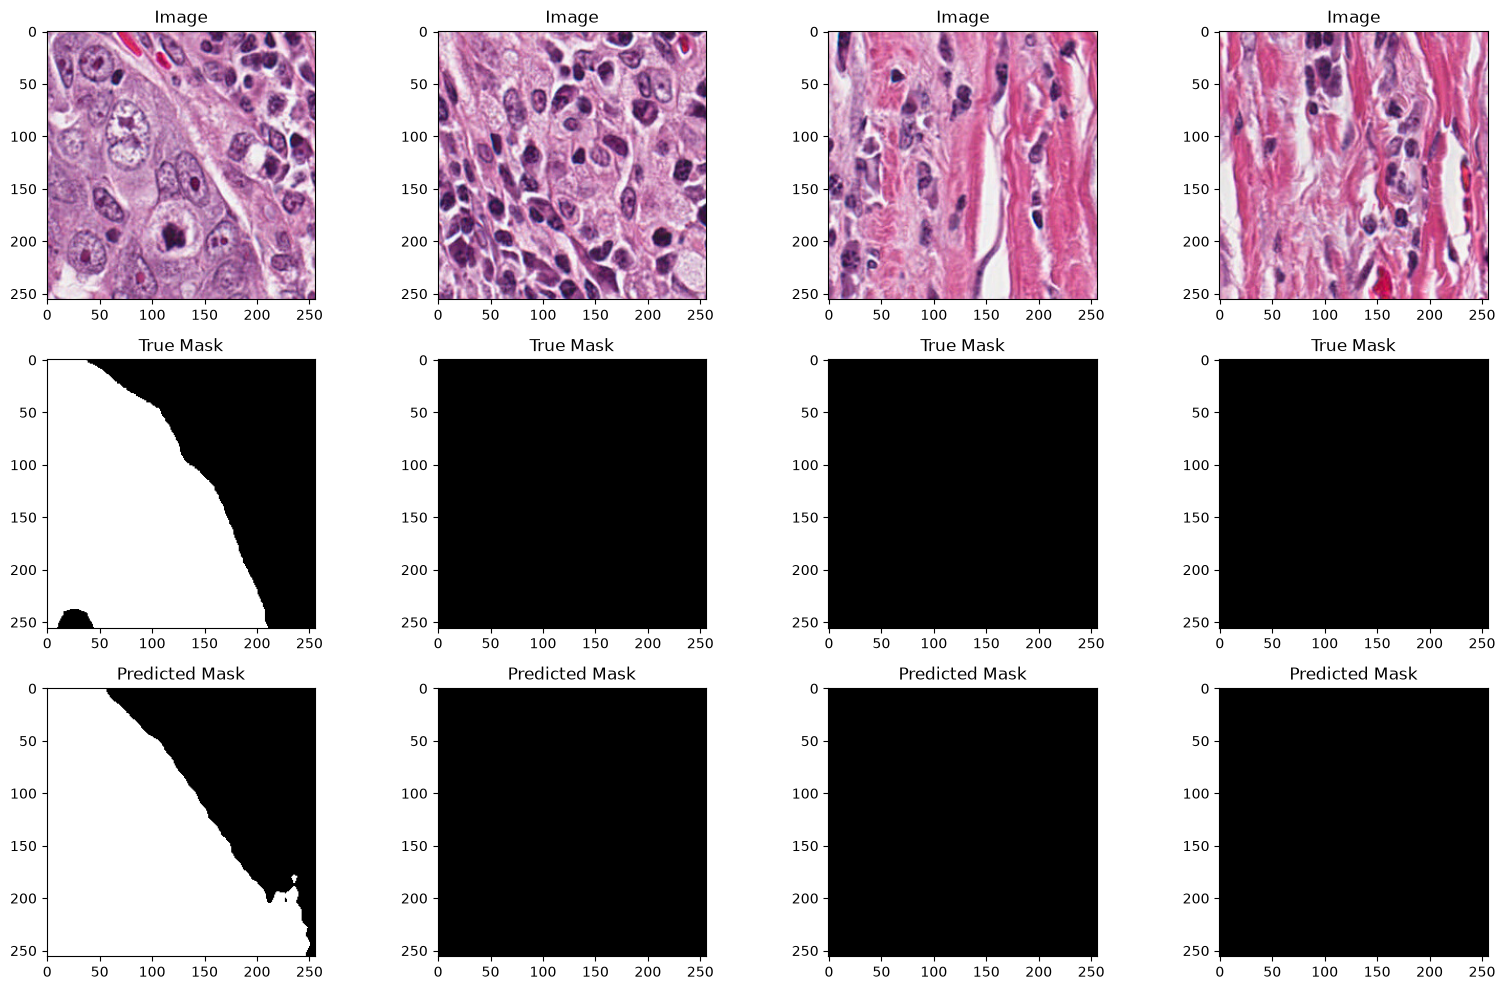

In [19]:
import random

best_model = deeplabv3_resnet50(weights="DEFAULT")
best_model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)
best_model.load_state_dict(torch.load("../notebooks/best_model_augmented.pth"))
best_model = best_model.to(device)
best_model.eval()

val_iter = iter(val_loader)
skip_batches = random.randint(0, len(val_loader) - 1)
for _ in range(skip_batches):
    next(val_iter)

imgs, masks = next(val_iter)
imgs, masks = imgs.to(device), masks.to(device)

with torch.no_grad():
    preds = torch.sigmoid(best_model(imgs)['out']) > 0.5

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i in range(4):
    img_disp = imgs[i].cpu().permute(1,2,0).numpy()
    img_disp = img_disp * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    img_disp = np.clip(img_disp, 0, 1)

    axes[0, i].imshow(img_disp)
    axes[0, i].set_title("Image")
    axes[1, i].imshow(masks[i].cpu().squeeze(), cmap="gray")
    axes[1, i].set_title("True Mask")
    axes[2, i].imshow(preds[i].cpu().squeeze(), cmap="gray")
    axes[2, i].set_title("Predicted Mask")

plt.tight_layout()
plt.savefig("../notebooks/prediction_results_augmented.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
imgs, masks = next(val_iter)
imgs, masks = imgs.to(device), masks.to(device)

with torch.no_grad():
    preds = torch.sigmoid(best_model(imgs)['out']) > 0.5

for i in range(len(imgs)):
    true_ratio = masks[i].mean().item()
    pred_ratio = preds[i].float().mean().item()
    print(f"Sample {i}: True tumor ratio={true_ratio:.2f}, Predicted tumor ratio={pred_ratio:.2f}")

Sample 0: True tumor ratio=0.34, Predicted tumor ratio=0.48
Sample 1: True tumor ratio=0.77, Predicted tumor ratio=0.81
Sample 2: True tumor ratio=0.82, Predicted tumor ratio=0.96
Sample 3: True tumor ratio=0.26, Predicted tumor ratio=0.24
Sample 4: True tumor ratio=0.88, Predicted tumor ratio=0.96
Sample 5: True tumor ratio=0.73, Predicted tumor ratio=0.88
Sample 6: True tumor ratio=0.07, Predicted tumor ratio=0.01
